# Etablish Baseline

### 1. Goal And Setup

Question: How much of UdonPred's apparent performance is above trivial sequence signal,
random-label training, and annotation noise?


In [16]:
# !pip install -r ../requirements.txt

from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"


### 2. Load  or Calculate Raw UdonPred 7x7 Matrix

In [12]:
# check if matrix already exists
matrix_csv = RESULTS / "udonpred_matrix" / "matrix.csv"
if not matrix_csv.exists():
    print("Running UdonPred matrix computation...")
    # !python ../scripts/run_udonpred_matrix.py --output_dir ../results/udonpred_matrix --device cpu
else:
    print("UdonPred matrix already exists, skipping computation.")

udon_matrix = pd.read_csv(RESULTS / "udonpred_matrix" / "matrix.csv")
udon_matrix

UdonPred matrix already exists, skipping computation.


,train_dataset,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot\n(AP),disprot\n(AUROC)
0,trizod,0.507853,0.707732,0.257050,-0.005696,0.412662,0.718810,0.898505,0.929508
1,chezod,0.486243,0.691124,0.234814,-0.038872,0.326703,0.713062,0.889928,0.925150
2,softdis,0.470177,0.536943,0.499879,0.149685,0.596582,0.784314,0.872120,0.917547
3,pdbflex,0.286765,0.285551,0.291659,0.395383,0.349231,0.519823,0.519235,0.737309
4,atlas,0.399847,0.594801,0.309795,0.055761,0.708063,0.718784,0.870035,0.920100
5,plddt,0.422638,0.624582,0.283637,0.103985,0.512167,0.838924,0.874971,0.927180
6,disprot,0.364121,0.663372,0.254746,0.098709,0.623971,0.774079,0.935162,0.958705


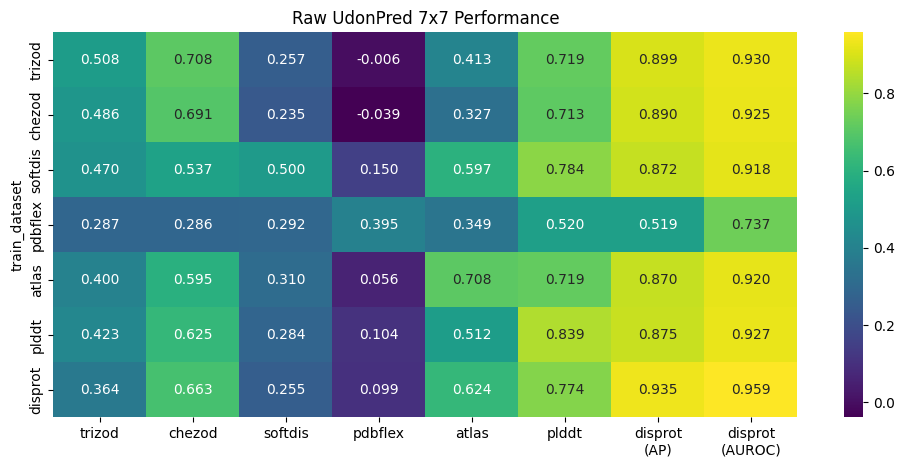

In [13]:
metric_cols = [
    "trizod", "chezod", "softdis", "pdbflex",
    "atlas", "plddt", "disprot\n(AP)", "disprot\n(AUROC)"
]
plt.figure(figsize=(12, 5))
sns.heatmap(
    udon_matrix.set_index("train_dataset")[metric_cols],
    annot=True,
    fmt=".3f",
    cmap="viridis",
)
plt.title("Raw UdonPred 7x7 Performance")
plt.show()


### 3. Create Simple Baseline

Amino acid composition logistic regression estimates how much signal is recoverable from global sequence composition.
Coil propensity estimates how much local secondary-structure-like signal explains disorder labels.

The idea is to test the model in the same way as UdonPred to obtain a comparable 7x7 matrix.

In [14]:
if (RESULTS / "simple_baselines" / "matrix.csv").exists():
    print("Baseline matrix already exists, skipping computation.")
else:
    print("Running simple baselines matrix computation...")
    # !python ../scripts/run_simple_baselines.py

baseline_matrix = pd.read_csv(RESULTS / "simple_baselines" / "matrix.csv")
baseline_matrix

Baseline matrix already exists, skipping computation.


,baseline,train_dataset,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot\n(AP),disprot\n(AUROC)
0,aa_composition_logreg,trizod,0.195902,0.507563,0.044220,-0.005160,0.209722,0.311141,0.625382,0.753995
1,aa_composition_logreg,chezod,0.196422,0.530384,0.041916,-0.022796,0.188351,0.313210,0.639465,0.747486
2,aa_composition_logreg,softdis,0.072778,0.220479,0.063046,0.148319,0.304284,0.204617,0.458099,0.639652
3,aa_composition_logreg,pdbflex,-0.067947,-0.200473,0.016496,0.196044,0.067581,-0.139738,0.291242,0.396673
4,aa_composition_logreg,atlas,0.047229,0.303521,0.053872,0.102446,0.255967,0.205078,0.487039,0.627038
5,aa_composition_logreg,plddt,0.177596,0.484770,0.052803,0.020923,0.259729,0.328734,0.597429,0.734311
6,aa_composition_logreg,disprot,0.165639,0.536459,0.037801,-0.017021,0.104685,0.323943,0.621937,0.735986
7,coil_propensity,none,0.273706,0.228599,0.200564,0.062577,0.149079,0.231114,0.480808,0.644659


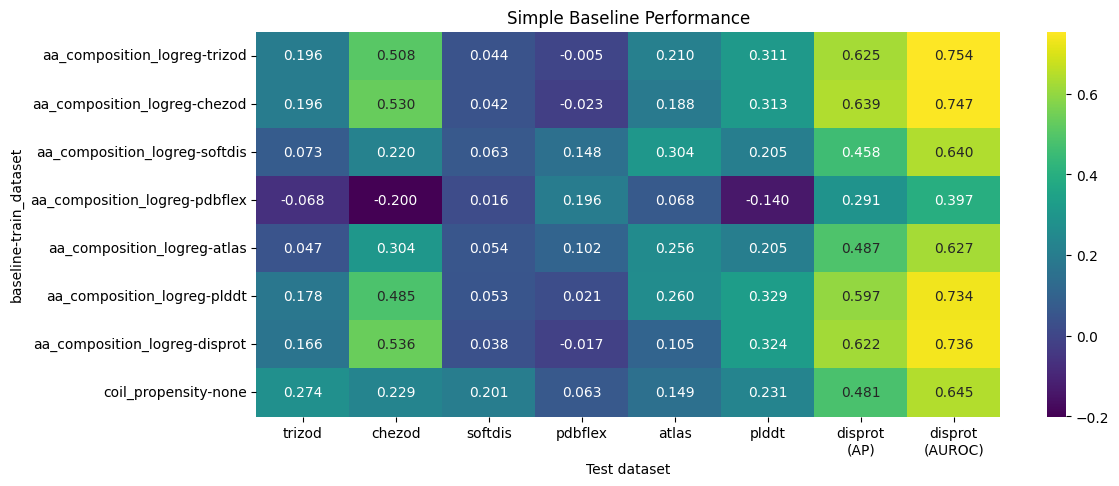

In [15]:
simple_plot = baseline_matrix.set_index(["baseline", "train_dataset"])[metric_cols]

plt.figure(figsize=(12, 5))
sns.heatmap(simple_plot, annot=True, fmt=".3f", cmap="viridis")
plt.xlabel("Test dataset")
plt.title("Simple Baseline Performance")
plt.show()
